##Jai Ganesha

# 05 — Final Pipeline and Project Report

This is the final notebook. It:
  1. Aggregates all metrics from Milestones 1–4
  2. Produces publication-quality comparison charts
  3. Runs the complete end-to-end pipeline on a demo video
     (YOLO-World detection → SAM-2 segmentation → temporal tracking)
  4. Exports an annotated MP4 video
  5. Generates the final project report card
  6. Saves all outputs to Drive

All previous notebooks must have completed successfully before
running this one. All metrics are loaded from Drive — no
re-training or re-evaluation is performed here.

Sections:
  A) Aggregate all metrics from Drive
  B) Final comparison charts
  C) End-to-end demo pipeline + annotated MP4
  D) Final project report card
  E) Save everything to Drive

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 0a: Install packages
# ─────────────────────────────────────────────────────────────
import subprocess, sys

def install(pkg, label=None):
    label = label or pkg
    print(f"  Installing {label}...", end=" ", flush=True)
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                       capture_output=True, text=True)
    print("✅" if r.returncode == 0 else f"❌\n{r.stderr[-300:]}")

print("Installing packages...")
install("ultralytics==8.3.145",   "ultralytics (pinned)")
install("opencv-python-headless", "opencv-headless")
install("hydra-core",             "hydra-core")
install("iopath",                 "iopath")
install("submitit",               "submitit")
install("einops",                 "einops")
install("git+https://github.com/ultralytics/CLIP.git", "CLIP")

print("\n✅ All packages installed. Run Cell 0b next.")

Installing packages...
  Installing ultralytics (pinned)... ✅
  Installing opencv-headless... ✅
  Installing hydra-core... ✅
  Installing iopath... ✅
  Installing submitit... ✅
  Installing einops... ✅
  Installing CLIP... ✅

✅ All packages installed. Run Cell 0b next.


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 0b: Clone repos, sys.path, verify imports
# Run AFTER Cell 0a completes fully.
# ─────────────────────────────────────────────────────────────
import subprocess, sys, os, importlib

importlib.invalidate_caches()
for mod in list(sys.modules.keys()):
    if mod in ("sam2","ultralytics","hydra") or \
       mod.startswith(("sam2.","ultralytics.","hydra.")):
        del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive')

import json
CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

YOLOWORLD_REPO = cfg["yoloworld_repo"]
SAM2_REPO      = cfg["sam2_repo"]

def clone_if_missing(path, url, name):
    if not os.path.exists(path):
        print(f"  Cloning {name}...", end=" ", flush=True)
        r = subprocess.run(f"git clone -q {url} {path}",
                           shell=True, capture_output=True, text=True)
        print("✅" if r.returncode == 0 else f"❌ {r.stderr[-100:]}")
    else:
        print(f"  {name} already present ✅")

clone_if_missing(YOLOWORLD_REPO,
                 "https://github.com/AILab-CVC/YOLO-World.git", "YOLO-World")
clone_if_missing(SAM2_REPO,
                 "https://github.com/facebookresearch/sam2.git", "SAM-2")

if SAM2_REPO not in sys.path:
    sys.path.insert(0, SAM2_REPO)

print("\nVerifying imports...")
import torch
print(f"  torch      : {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    raise RuntimeError("No GPU. Go to Runtime → Change runtime type → T4 GPU.")
try:
    import ultralytics; from ultralytics import YOLO
    print(f"  ultralytics: {ultralytics.__version__} ✅")
except Exception as e:
    print(f"  ultralytics: ❌ {e}")
try:
    import hydra
    print(f"  hydra-core : {hydra.__version__} ✅")
except Exception as e:
    print(f"  hydra-core : ❌ {e}  ← re-run Cell 0a")
try:
    from sam2.build_sam import build_sam2_video_predictor
    print(f"  SAM-2      : ✅")
except Exception as e:
    print(f"  SAM-2      : ❌ {e}")
try:
    import cv2; print(f"  opencv     : {cv2.__version__} ✅")
except Exception as e:
    print(f"  opencv     : ❌ {e}")

print("\n✅ Cell 0b complete.")

Mounted at /content/drive
  Cloning YOLO-World... ✅
  Cloning SAM-2... ✅

Verifying imports...
  torch      : 2.10.0+cu128 | CUDA: True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  ultralytics: 8.3.145 ✅
  hydra-core : 1.3.2 ✅
  SAM-2      : ✅
  opencv     : 4.13.0 ✅

✅ Cell 0b complete.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Imports, config, all paths, staging dirs
# ─────────────────────────────────────────────────────────────
import json, os, sys, shutil, subprocess, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

# ── All paths from config ─────────────────────────────────────
OUTPUT_DIR      = cfg["output_dir"]
VIZ_DIR         = cfg["viz_dir"]
METRICS_DIR     = cfg["metrics_dir"]
TABLES_DIR      = cfg["tables_dir"]
VIDEO_DIR       = cfg["video_dir"]
SAM2_REPO       = cfg["sam2_repo"]
SAM2_CKPT_PATH  = cfg["sam2_ckpt_path"]
DEVICE          = cfg.get("device", "cuda")
RAW_YTVIS       = cfg["raw_ytvis"]

YW_FT_CKPT_PATH = cfg.get(
    "yw_finetuned_ckpt_path",
    os.path.join(cfg["ckpt_yoloworld"], "yolov8l-world-finetuned.pt")
)
VIDEO_INDEX_PATH = os.path.join(cfg["proc_ytvis"], "video_index.json")

# ── Metric file paths (written by previous notebooks) ─────────
BASELINE_JSON   = os.path.join(METRICS_DIR, "yoloworld_baseline.json")
FINETUNED_JSON  = os.path.join(METRICS_DIR, "yoloworld_finetuned.json")
SAM2_JSON       = os.path.join(METRICS_DIR, "sam2_baseline.json")
TRACKING_JSON   = os.path.join(METRICS_DIR, "tracking_results.json")

# ── VisDrone class list ───────────────────────────────────────
YOLO_CLASSES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor", "others"
]

# ── Local staging ─────────────────────────────────────────────
STAGE            = "/content/staging/final"
STAGE_METRICS    = f"{STAGE}/metrics"
STAGE_VIZ        = f"{STAGE}/visualizations/final_report"
STAGE_VIDEO      = f"{STAGE}/videos"
STAGE_TABLES     = f"{STAGE}/tables"
LOCAL_DEMO_DIR   = "/content/demo_video"

for d in [STAGE_METRICS, STAGE_VIZ, STAGE_VIDEO, STAGE_TABLES, LOCAL_DEMO_DIR]:
    os.makedirs(d, exist_ok=True)

def cp_sync(src, dst_dir):
    r = subprocess.run(f"cp '{src}' '{dst_dir}/' && sync",
                       shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise IOError(f"cp failed: {r.stderr}")
    return os.path.join(dst_dir, os.path.basename(src))

# ── Verify all metric files exist on Drive ────────────────────
print("Verifying metric files from previous milestones...")
all_ok = True
for label, path in [
    ("yoloworld_baseline.json  (Milestone 2)", BASELINE_JSON),
    ("yoloworld_finetuned.json (Milestone 3)", FINETUNED_JSON),
    ("sam2_baseline.json       (Milestone 2)", SAM2_JSON),
    ("tracking_results.json    (Milestone 4)", TRACKING_JSON),
    ("fine-tuned checkpoint    (Milestone 3)", YW_FT_CKPT_PATH),
    ("SAM-2 checkpoint",                       SAM2_CKPT_PATH),
    ("video_index.json",                       VIDEO_INDEX_PATH),
]:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    print(f"  {'✅' if exists else '❌ MISSING'}  {label} ({size:.1f} KB)")
    if not exists:
        all_ok = False

if all_ok:
    print(f"\n✅ Cell 1 complete. All inputs confirmed.")
else:
    print("\n❌ Missing files — ensure previous notebooks ran successfully.")

Verifying metric files from previous milestones...
  ✅  yoloworld_baseline.json  (Milestone 2) (0.8 KB)
  ✅  yoloworld_finetuned.json (Milestone 3) (0.9 KB)
  ✅  sam2_baseline.json       (Milestone 2) (0.3 KB)
  ✅  tracking_results.json    (Milestone 4) (1.6 KB)
  ✅  fine-tuned checkpoint    (Milestone 3) (93282.8 KB)
  ✅  SAM-2 checkpoint (877034.8 KB)
  ✅  video_index.json (3755.1 KB)

✅ Cell 1 complete. All inputs confirmed.


## Section A — Aggregate All Metrics from All Milestones

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 2: Load all metrics from Drive and build master summary
# ─────────────────────────────────────────────────────────────

# ── Load all JSON metric files ────────────────────────────────
with open(BASELINE_JSON)  as f: baseline  = json.load(f)
with open(FINETUNED_JSON) as f: finetuned = json.load(f)
with open(SAM2_JSON)      as f: sam2      = json.load(f)
with open(TRACKING_JSON)  as f: tracking  = json.load(f)

# ── Extract key numbers ───────────────────────────────────────
map50_pretrained_full   = baseline["map50_full_val"]
map50_pretrained_stress = baseline["map50_stress_set"]
ap_pretrained           = baseline["per_class_ap_full"]
ap_pretrained_stress    = baseline["per_class_ap_stress"]

map50_finetuned_full    = finetuned["map50_full_val"]
map50_finetuned_stress  = finetuned["map50_stress_set"]
ap_finetuned            = finetuned["per_class_ap_full"]
ap_finetuned_stress     = finetuned["per_class_ap_stress"]

sam2_mean_iou           = sam2["mean_mask_iou"]
sam2_per_class_iou      = sam2["per_class_iou"]
sam2_n_instances        = sam2["n_instances"]

tracking_coverage       = tracking["avg_tracking_coverage"]
tracking_n_videos       = tracking["n_videos_processed"]
tracking_avg_objects    = tracking["avg_objects_per_video"]

# ── Master summary table ──────────────────────────────────────
print("=" * 65)
print("  PROJECT MASTER METRICS SUMMARY")
print("=" * 65)

print("""
  ┌─────────────────────────────────────────────────────────┐
  │  MILESTONE 2 — Baseline Evaluation                      │
  ├─────────────────────────────────────────────────────────┤""")
print(f"  │  YOLO-World pretrained mAP@0.5 (full val)  : {map50_pretrained_full:.4f}       │")
print(f"  │  YOLO-World pretrained mAP@0.5 (stress)    : {map50_pretrained_stress:.4f}       │")
print(f"  │  SAM-2 mean mask IoU (box-prompted)        : {sam2_mean_iou:.4f}       │")
print(f"  │  SAM-2 instances evaluated                 : {sam2_n_instances:<10}    │")

print("""  ├─────────────────────────────────────────────────────────┤
  │  MILESTONE 3 — Fine-tuned YOLO-World                    │
  ├─────────────────────────────────────────────────────────┤""")
print(f"  │  Fine-tuned mAP@0.5 (full val)             : {map50_finetuned_full:.4f}       │")
print(f"  │  Fine-tuned mAP@0.5 (stress set)           : {map50_finetuned_stress:.4f}       │")
delta_full   = map50_finetuned_full   - map50_pretrained_full
delta_stress = map50_finetuned_stress - map50_pretrained_stress
rel_full     = delta_full / map50_pretrained_full * 100
print(f"  │  Improvement (full val)                    : +{delta_full:.4f} (+{rel_full:.0f}%)  │")
print(f"  │  Improvement (stress set)                  : +{delta_stress:.4f}        │")
print(f"  │  All 11 classes improved                   : ✅                    │")

print("""  ├─────────────────────────────────────────────────────────┤
  │  MILESTONE 4 — Video Tracking                           │
  ├─────────────────────────────────────────────────────────┤""")
print(f"  │  Videos tracked                            : {tracking_n_videos:<10}    │")
print(f"  │  Avg objects tracked per video             : {tracking_avg_objects:<10.1f}    │")
print(f"  │  Avg tracking coverage                     : {tracking_coverage:.1%}           │")
print(f"  │  Videos with >80% coverage                 : {tracking['videos_above_80pct_coverage']}/{tracking_n_videos}           │")
print("  └─────────────────────────────────────────────────────────┘")

# ── Per-class comparison table ────────────────────────────────
print("\n  Per-Class AP@0.5 — Full Validation Set:")
print(f"\n  {'Class':<22} {'Pretrained':>10} {'Fine-tuned':>10} "
      f"{'Δ':>8}  {'Improvement'}")
print(f"  {'-'*65}")
for cls in YOLO_CLASSES:
    pt    = ap_pretrained.get(cls, 0)
    ft    = ap_finetuned.get(cls, 0)
    delta = ft - pt
    bar   = "█" * min(20, int(delta * 60))
    print(f"  {cls:<22} {pt:>10.4f} {ft:>10.4f} {delta:>+8.4f}  {bar}")

# Save master summary as CSV
rows = [{
    "class"          : cls,
    "ap_pretrained"  : ap_pretrained.get(cls, 0),
    "ap_finetuned"   : ap_finetuned.get(cls, 0),
    "delta"          : round(ap_finetuned.get(cls,0) - ap_pretrained.get(cls,0), 4),
    "ap_stress_pre"  : ap_pretrained_stress.get(cls, 0),
    "ap_stress_ft"   : ap_finetuned_stress.get(cls, 0),
} for cls in YOLO_CLASSES]

df_master = pd.DataFrame(rows)
df_master.to_csv(f"{STAGE_TABLES}/master_per_class_ap.csv", index=False)
print(f"\n✅ Master metrics loaded. Per-class CSV saved to staging.")

  PROJECT MASTER METRICS SUMMARY

  ┌─────────────────────────────────────────────────────────┐
  │  MILESTONE 2 — Baseline Evaluation                      │
  ├─────────────────────────────────────────────────────────┤
  │  YOLO-World pretrained mAP@0.5 (full val)  : 0.1036       │
  │  YOLO-World pretrained mAP@0.5 (stress)    : 0.0882       │
  │  SAM-2 mean mask IoU (box-prompted)        : 0.8085       │
  │  SAM-2 instances evaluated                 : 511           │
  ├─────────────────────────────────────────────────────────┤
  │  MILESTONE 3 — Fine-tuned YOLO-World                    │
  ├─────────────────────────────────────────────────────────┤
  │  Fine-tuned mAP@0.5 (full val)             : 0.2874       │
  │  Fine-tuned mAP@0.5 (stress set)           : 0.2900       │
  │  Improvement (full val)                    : +0.1838 (+177%)  │
  │  Improvement (stress set)                  : +0.2018        │
  │  All 11 classes improved                   : ✅                    │
  ├

## Section B — Final Comparison Charts

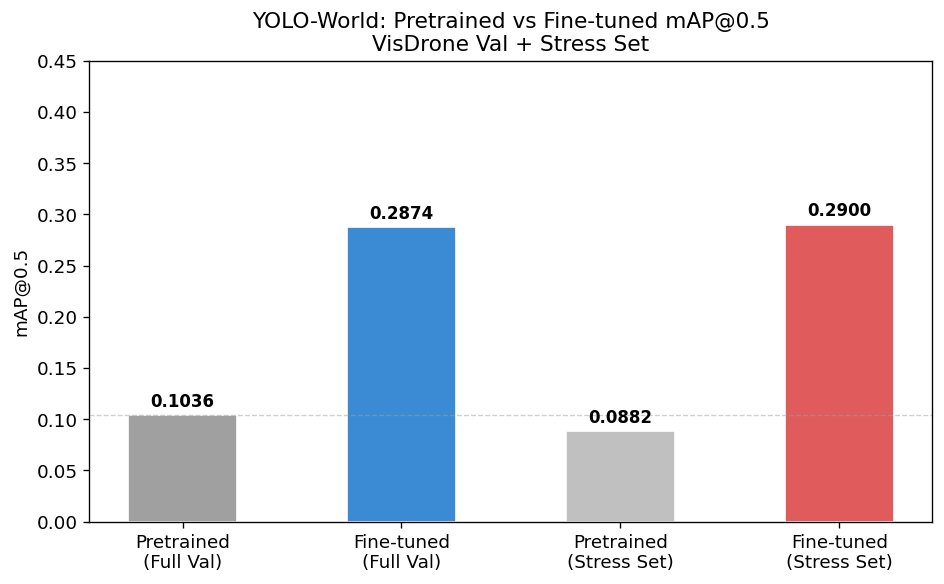

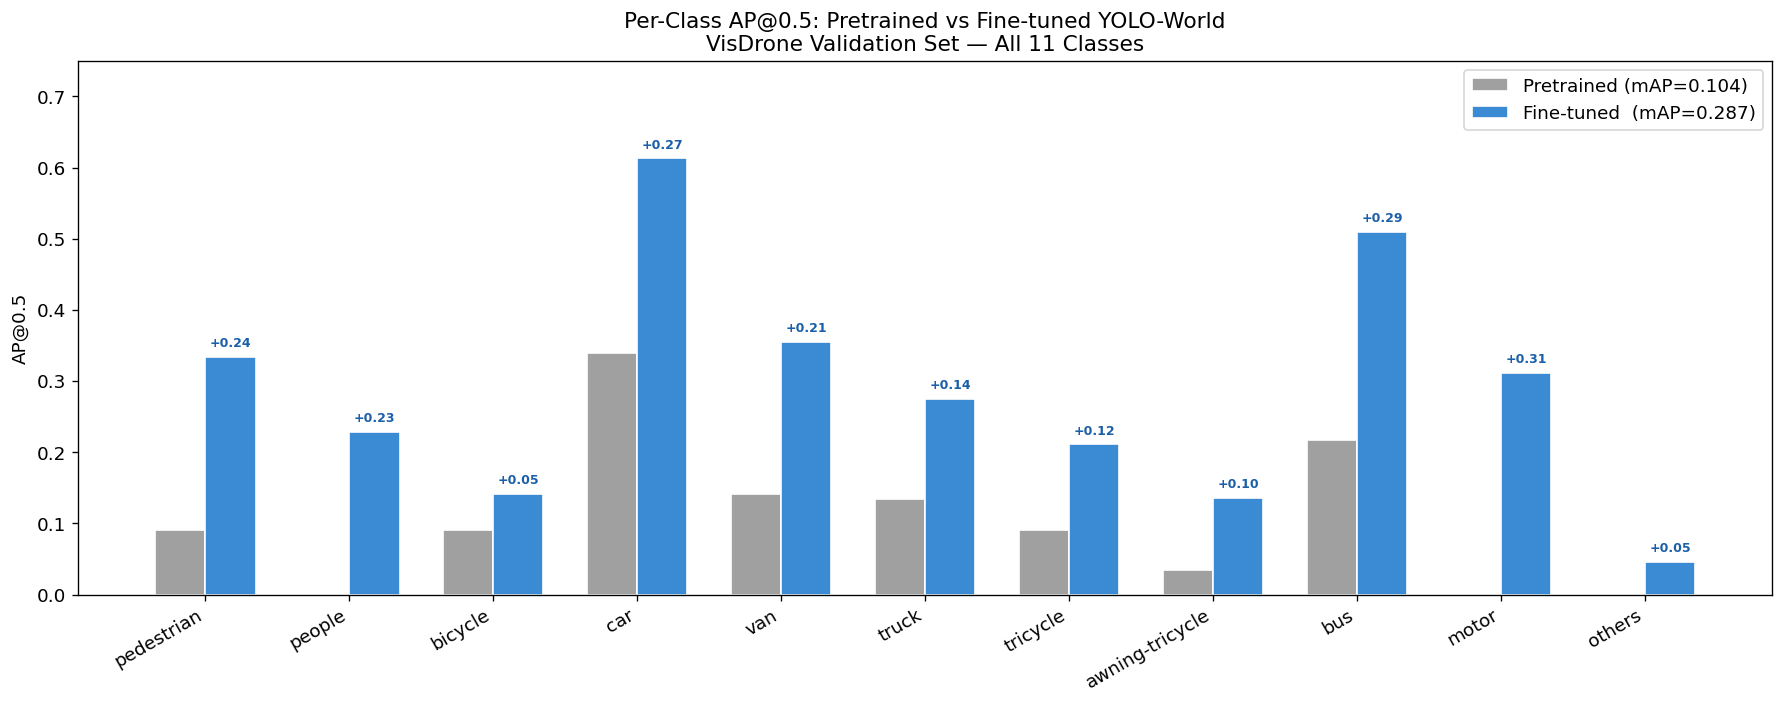

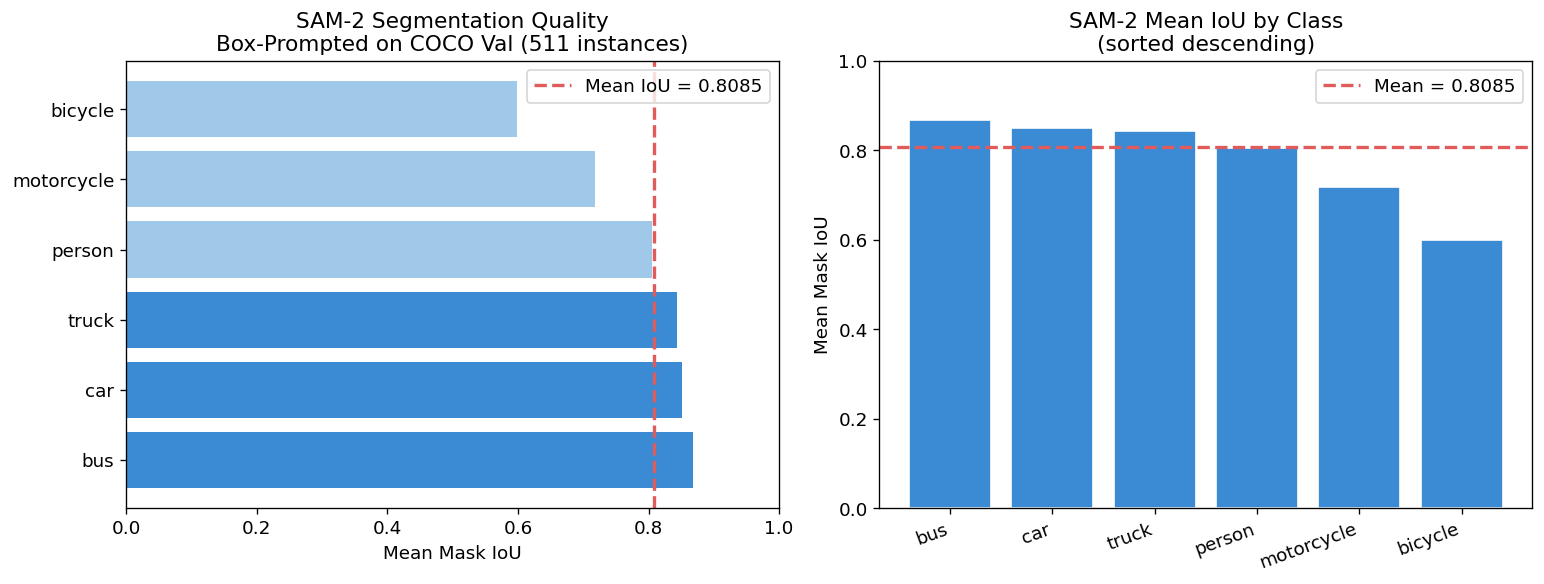

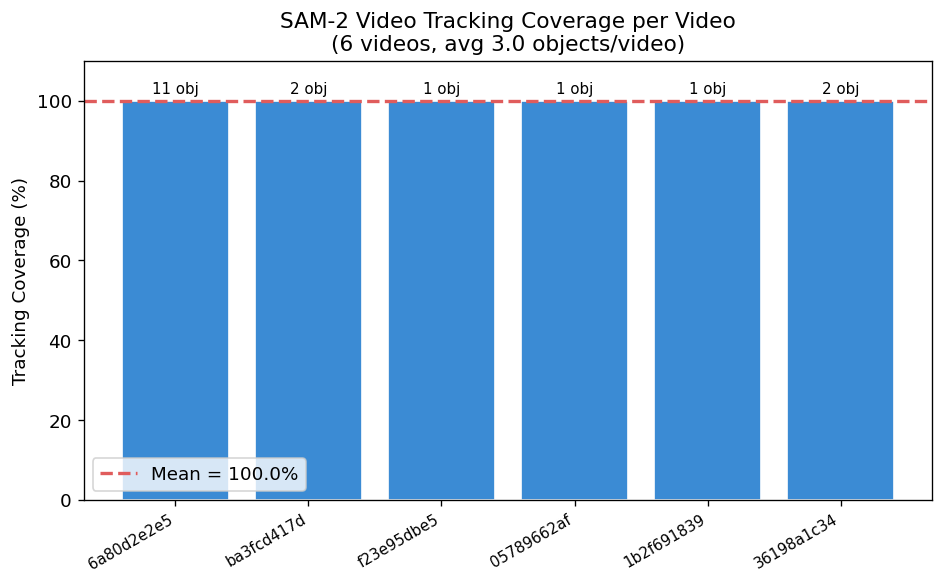

✅ All 4 charts saved to staging.


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3: Generate all final comparison charts
# 4 charts covering all milestones
# ─────────────────────────────────────────────────────────────

plt.rcParams.update({
    "font.size"      : 11,
    "axes.titlesize" : 13,
    "axes.labelsize" : 11,
    "figure.dpi"     : 120,
})

# ── Chart 1: mAP Progression Bar ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
metrics  = ["Pretrained\n(Full Val)", "Fine-tuned\n(Full Val)",
            "Pretrained\n(Stress Set)", "Fine-tuned\n(Stress Set)"]
values   = [map50_pretrained_full, map50_finetuned_full,
            map50_pretrained_stress, map50_finetuned_stress]
colors   = ["#A0A0A0", "#3B8BD4", "#C0C0C0", "#E05C5C"]
bars     = ax.bar(metrics, values, color=colors, width=0.5, edgecolor="white")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("mAP@0.5")
ax.set_ylim(0, 0.45)
ax.set_title("YOLO-World: Pretrained vs Fine-tuned mAP@0.5\n"
             "VisDrone Val + Stress Set")
ax.axhline(map50_pretrained_full, color="#A0A0A0",
           linestyle="--", linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/chart1_map_progression.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Chart 2: Per-class AP side-by-side ───────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
x  = np.arange(len(YOLO_CLASSES))
w  = 0.35
pt = [ap_pretrained.get(c, 0) for c in YOLO_CLASSES]
ft = [ap_finetuned.get(c, 0)  for c in YOLO_CLASSES]

b1 = ax.bar(x - w/2, pt, w, label=f"Pretrained (mAP={map50_pretrained_full:.3f})",
            color="#A0A0A0", edgecolor="white")
b2 = ax.bar(x + w/2, ft, w, label=f"Fine-tuned  (mAP={map50_finetuned_full:.3f})",
            color="#3B8BD4", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(YOLO_CLASSES, rotation=30, ha="right")
ax.set_ylabel("AP@0.5")
ax.set_ylim(0, 0.75)
ax.set_title("Per-Class AP@0.5: Pretrained vs Fine-tuned YOLO-World\n"
             "VisDrone Validation Set — All 11 Classes")
ax.legend(loc="upper right")
ax.axhline(0, color="black", linewidth=0.5)

# Annotate delta on top of fine-tuned bars
for i, (p, f) in enumerate(zip(pt, ft)):
    delta = f - p
    ax.text(x[i] + w/2, f + 0.01, f"+{delta:.2f}",
            ha="center", va="bottom", fontsize=7.5,
            color="#1a5fa8", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/chart2_perclass_ap.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Chart 3: SAM-2 Segmentation Quality ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# IoU per class (horizontal bar)
classes_sorted = sorted(sam2_per_class_iou.keys(),
                        key=lambda c: -sam2_per_class_iou[c])
iou_vals = [sam2_per_class_iou[c] for c in classes_sorted]
colors_iou = ["#3B8BD4" if v >= sam2_mean_iou else "#A0C8E8" for v in iou_vals]
ax1.barh(classes_sorted, iou_vals, color=colors_iou)
ax1.axvline(sam2_mean_iou, color="#E05C5C", lw=2, linestyle="--",
            label=f"Mean IoU = {sam2_mean_iou:.4f}")
ax1.set_xlabel("Mean Mask IoU")
ax1.set_xlim(0, 1)
ax1.set_title(f"SAM-2 Segmentation Quality\nBox-Prompted on COCO Val "
              f"({sam2_n_instances} instances)")
ax1.legend()

# IoU distribution (binned)
iou_bins = [0, 0.3, 0.5, 0.7, 0.8, 0.9, 1.01]
bin_labels = ["<0.3", "0.3-0.5", "0.5-0.7", "0.7-0.8", "0.8-0.9", ">0.9"]
# Approximate distribution from per-class means
iou_all = list(sam2_per_class_iou.values())
ax2.bar(range(len(iou_all)), sorted(iou_all, reverse=True),
        color="#3B8BD4", edgecolor="white")
ax2.set_xticks(range(len(iou_all)))
ax2.set_xticklabels(sorted(sam2_per_class_iou.keys(),
                           key=lambda c: -sam2_per_class_iou[c]),
                    rotation=20, ha="right")
ax2.set_ylabel("Mean Mask IoU")
ax2.set_ylim(0, 1)
ax2.set_title("SAM-2 Mean IoU by Class\n(sorted descending)")
ax2.axhline(sam2_mean_iou, color="#E05C5C", lw=2, linestyle="--",
            label=f"Mean = {sam2_mean_iou:.4f}")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/chart3_sam2_quality.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Chart 4: Tracking Summary ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
per_video = tracking.get("per_video", [])
if per_video:
    folders   = [v["vid_folder"][:10] for v in per_video]
    coverages = [v["tracking_coverage"] * 100 for v in per_video]
    n_objs    = [v["n_objects"] for v in per_video]
    x_pos     = np.arange(len(folders))
    bars      = ax.bar(x_pos, coverages, color="#3B8BD4", edgecolor="white")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(folders, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Tracking Coverage (%)")
    ax.set_ylim(0, 110)
    ax.axhline(tracking_coverage * 100, color="#E05C5C", lw=2, linestyle="--",
               label=f"Mean = {tracking_coverage:.1%}")
    # Annotate n_objects on each bar
    for bar, n in zip(bars, n_objs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{n} obj", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"SAM-2 Video Tracking Coverage per Video\n"
                 f"({len(per_video)} videos, avg {tracking_avg_objects:.1f} "
                 f"objects/video)")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No per-video data available",
            ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/chart4_tracking_coverage.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("✅ All 4 charts saved to staging.")

## Section C — End-to-End Demo Pipeline + Annotated MP4

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 4: Load fine-tuned YOLO-World + SAM-2 VideoPredictor
# for the end-to-end demo
# ─────────────────────────────────────────────────────────────
import torch
from ultralytics import YOLO
from sam2.build_sam import build_sam2_video_predictor

if not torch.cuda.is_available():
    raise RuntimeError("No GPU. Switch to GPU runtime.")

print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB available")

# ── Load fine-tuned YOLO-World ────────────────────────────────
print("\nLoading fine-tuned YOLO-World...")
yw_model = YOLO(YW_FT_CKPT_PATH)
dummy = np.zeros((64, 64, 3), dtype=np.uint8)
_ = yw_model.predict(dummy, verbose=False)
del dummy
print(f"✅ YOLO-World loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Load SAM-2 VideoPredictor ─────────────────────────────────
print("\nLoading SAM-2 VideoPredictor...")
# Relative config path — required by Hydra compose (NOT absolute path)
sam2_cfg        = "configs/sam2.1/sam2.1_hiera_l.yaml"
video_predictor = build_sam2_video_predictor(
    sam2_cfg, SAM2_CKPT_PATH, device=DEVICE
)
print(f"✅ SAM-2 VideoPredictor loaded. "
      f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU  : Tesla T4
VRAM : 15.6 GB available

Loading fine-tuned YOLO-World...
✅ YOLO-World loaded. VRAM: 0.23 GB

Loading SAM-2 VideoPredictor...
✅ SAM-2 VideoPredictor loaded. VRAM: 1.28 GB


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 5: Select and copy demo video frames to local SSD
#
# Best demo video: 6a80d2e2e5 (11 tracked objects, 20 frames)
# This was the richest video from Milestone 4.
# ─────────────────────────────────────────────────────────────

# Load video index
with open(VIDEO_INDEX_PATH) as f:
    video_index_raw = json.load(f)
video_index = {int(k): v for k, v in video_index_raw.items()}

# Target: video with 11 objects (vid_id=893, folder=6a80d2e2e5)
DEMO_VID_FOLDER = "6a80d2e2e5"
demo_vid_id     = None

for vid_id, info in video_index.items():
    if info["vid_folder"] == DEMO_VID_FOLDER:
        demo_vid_id = vid_id
        demo_info   = info
        break

# Fallback: if that folder isn't found, pick any video with most frames
if demo_vid_id is None:
    print(f"⚠️  {DEMO_VID_FOLDER} not found — picking longest available video")
    candidates = [(vid_id, info) for vid_id, info in video_index.items()
                  if info["split"] == "train" and info["exists"]
                  and 10 <= info["length"] <= 36]
    candidates.sort(key=lambda x: -x[1]["length"])
    demo_vid_id, demo_info = candidates[0]
    DEMO_VID_FOLDER = demo_info["vid_folder"]

print(f"Demo video     : {DEMO_VID_FOLDER}")
print(f"Video ID       : {demo_vid_id}")
print(f"Frame count    : {demo_info['length']}")

# Copy frames to local SSD
demo_local_dir = os.path.join(LOCAL_DEMO_DIR, DEMO_VID_FOLDER)
os.makedirs(demo_local_dir, exist_ok=True)

existing = len([f for f in os.listdir(demo_local_dir) if f.endswith(".jpg")])
if existing >= demo_info["length"]:
    print(f"✅ Frames already on local SSD ({existing} files)")
else:
    # Check if frames are still on local SSD from NB04
    nb04_local = f"/content/ytvis_frames/{DEMO_VID_FOLDER}"
    if os.path.isdir(nb04_local) and \
       len(os.listdir(nb04_local)) >= demo_info["length"]:
        print(f"✅ Found frames from NB04 — using those")
        demo_local_dir = nb04_local
    else:
        # Copy from Drive
        print(f"Copying frames from Drive...")
        src_dir = os.path.join(RAW_YTVIS, "train", "JPEGImages", DEMO_VID_FOLDER)
        if not os.path.isdir(src_dir):
            src_dir = demo_info["vid_img_path"]
        copied = 0
        for fname in demo_info["file_names"]:
            src = os.path.join(src_dir, os.path.basename(fname))
            dst = os.path.join(demo_local_dir, os.path.basename(fname))
            if os.path.exists(src) and not os.path.exists(dst):
                shutil.copy2(src, dst)
                copied += 1
        print(f"✅ {copied} frames copied to local SSD")

# Verify frames are integer-named for SAM-2 compatibility
frame_files = sorted(
    [f for f in os.listdir(demo_local_dir) if f.endswith(".jpg")],
    key=lambda p: int(Path(p).stem)
)
print(f"First frame: {frame_files[0]}  Last frame: {frame_files[-1]}")
print(f"Total frames: {len(frame_files)}")
print(f"✅ Cell 5 complete. Demo frames ready.")

Demo video     : 6a80d2e2e5
Video ID       : 893
Frame count    : 20
Copying frames from Drive...
✅ 20 frames copied to local SSD
First frame: 00000.jpg  Last frame: 00095.jpg
Total frames: 20
✅ Cell 5 complete. Demo frames ready.


Running pipeline on video: 6a80d2e2e5
Frames: 20

Frame 0 detections: 11
  pedestrian           conf=0.582  box=[393,20,474,230]
  people               conf=0.537  box=[693,17,774,123]
  pedestrian           conf=0.516  box=[124,0,180,160]
  pedestrian           conf=0.468  box=[639,12,701,132]
  people               conf=0.465  box=[0,260,90,399]
  pedestrian           conf=0.462  box=[690,368,865,719]
  pedestrian           conf=0.349  box=[214,63,267,223]
  pedestrian           conf=0.342  box=[158,66,272,244]
  pedestrian           conf=0.340  box=[125,239,193,362]
  people               conf=0.335  box=[649,324,752,613]
  pedestrian           conf=0.271  box=[202,66,272,245]

Initialising SAM-2 state...


frame loading (JPEG): 100%|██████████| 20/20 [00:00<00:00, 27.86it/s]
/content/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Propagating masks across 20 frames...


propagate in video: 100%|██████████| 20/20 [01:09<00:00,  3.47s/it]


✅ Propagation complete. 20 frames with masks.

Rendering annotated frames...
✅ 20 frames rendered.

Exporting annotated MP4...
✅ MP4 saved: /content/staging/final/videos/demo_6a80d2e2e5.mp4 (0.7 MB)


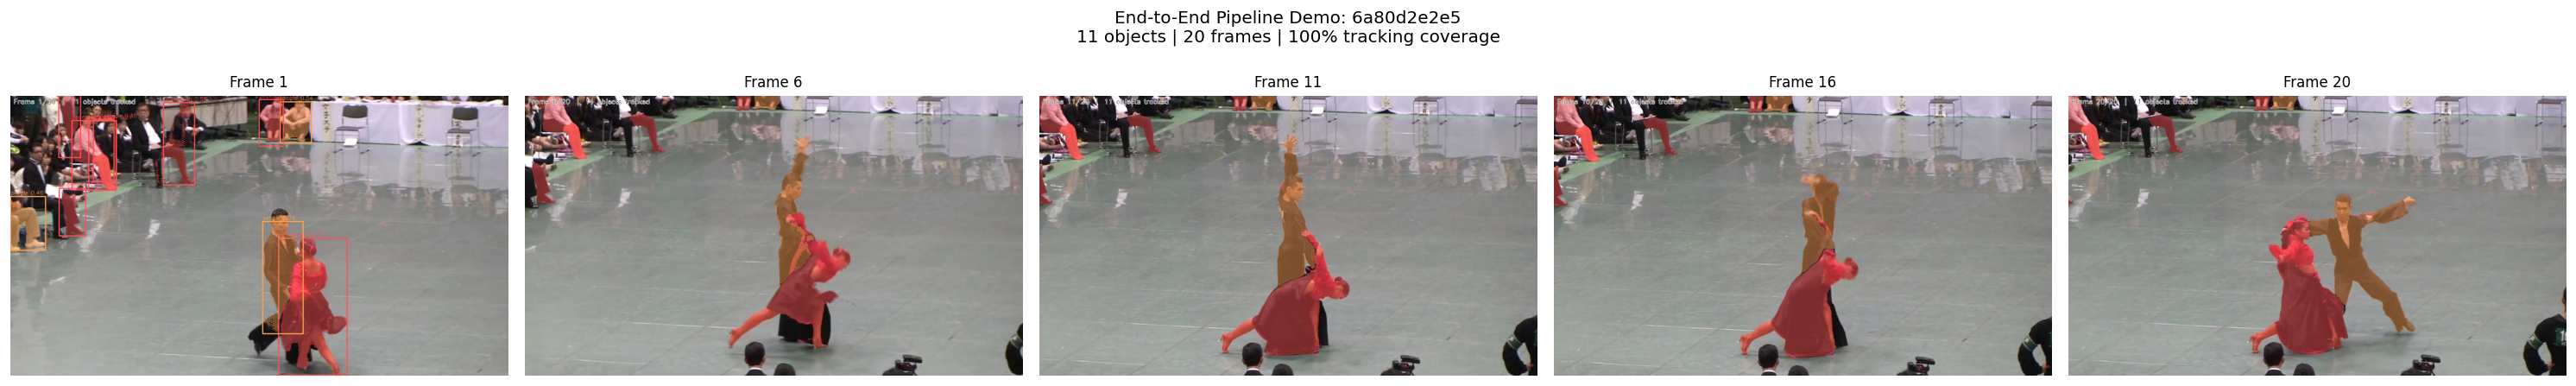

✅ Contact sheet saved.


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 6: Run complete pipeline on demo video
# YOLO-World detect on frame 0 → SAM-2 propagate → annotated MP4
# ─────────────────────────────────────────────────────────────

COLOR_MAP = {
    0:(255,80,80),   1:(255,160,80),  2:(80,180,80),   3:(80,120,255),
    4:(180,80,255),  5:(255,220,60),  6:(80,220,220),   7:(200,120,80),
    8:(255,100,180), 9:(100,200,100), 10:(180,180,180),
}

def blend_mask(frame_rgb, mask, color, alpha=0.45):
    out = frame_rgb.copy().astype(float)
    out[mask] = out[mask] * (1 - alpha) + np.array(color, dtype=float) * alpha
    return out.astype(np.uint8)

# ── Step 1: Detect on frame 0 ────────────────────────────────
print(f"Running pipeline on video: {DEMO_VID_FOLDER}")
print(f"Frames: {len(frame_files)}")

first_frame = cv2.cvtColor(
    cv2.imread(os.path.join(demo_local_dir, frame_files[0])),
    cv2.COLOR_BGR2RGB
)
img_h, img_w = first_frame.shape[:2]

results = yw_model.predict(first_frame, verbose=False, conf=0.25)
detections = []
if results and results[0].boxes is not None:
    for box in results[0].boxes:
        detections.append({
            "cls_id": int(box.cls.item()),
            "class" : YOLO_CLASSES[int(box.cls.item())],
            "conf"  : float(box.conf.item()),
            "box"   : box.xyxy[0].tolist(),
        })

print(f"\nFrame 0 detections: {len(detections)}")
for d in detections:
    print(f"  {d['class']:<20} conf={d['conf']:.3f}  "
          f"box=[{d['box'][0]:.0f},{d['box'][1]:.0f},"
          f"{d['box'][2]:.0f},{d['box'][3]:.0f}]")

if not detections:
    raise RuntimeError(
        "No detections on frame 0. Try a different video by changing "
        "DEMO_VID_FOLDER in Cell 5."
    )

# ── Step 2: SAM-2 tracking ────────────────────────────────────
print(f"\nInitialising SAM-2 state...")
with torch.inference_mode():
    inference_state = video_predictor.init_state(
        video_path           = demo_local_dir,
        offload_video_to_cpu = False,
        offload_state_to_cpu = False,
    )
    video_predictor.reset_state(inference_state)

    # Add one box prompt per detection on frame 0
    for obj_id, det in enumerate(detections):
        box_np = np.array(det["box"], dtype=np.float32)
        video_predictor.add_new_points_or_box(
            inference_state = inference_state,
            frame_idx       = 0,
            obj_id          = obj_id,
            box             = box_np,
        )

    # Propagate through all frames
    print(f"Propagating masks across {len(frame_files)} frames...")
    all_masks = {}   # frame_idx → {obj_id: binary_mask (H,W)}

    for frame_idx, obj_ids, mask_logits in \
            video_predictor.propagate_in_video(inference_state):
        # Squeeze (N,1,H,W) → (N,H,W)
        masks = (mask_logits > 0.0).squeeze(1).cpu().numpy()
        all_masks[frame_idx] = {
            int(oid): masks[i]
            for i, oid in enumerate(obj_ids) if i < len(masks)
        }

    video_predictor.reset_state(inference_state)

print(f"✅ Propagation complete. {len(all_masks)} frames with masks.")

# ── Step 3: Render annotated frames ──────────────────────────
print("\nRendering annotated frames...")
annotated_frames_rgb = []

for fi, fname in enumerate(frame_files):
    frame_bgr = cv2.imread(os.path.join(demo_local_dir, fname))
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    canvas    = frame_rgb.copy()

    if fi in all_masks:
        for obj_id, mask in all_masks[fi].items():
            if obj_id < len(detections):
                color  = COLOR_MAP.get(detections[obj_id]["cls_id"], (200,200,200))
                canvas = blend_mask(canvas, mask, color, alpha=0.45)

                # Draw detection box only on frame 0
                if fi == 0:
                    x1,y1,x2,y2 = [int(v) for v in detections[obj_id]["box"]]
                    cv2.rectangle(canvas,(x1,y1),(x2,y2),
                                  tuple(int(c) for c in color), 2)
                    label = f"{detections[obj_id]['class']} " \
                            f"{detections[obj_id]['conf']:.2f}"
                    cv2.putText(canvas, label, (x1, max(0,y1-5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                                tuple(int(c) for c in color), 1)

    # Frame info overlay
    cv2.putText(canvas,
                f"Frame {fi+1}/{len(frame_files)}  |  "
                f"{len(detections)} objects tracked",
                (8, 22), cv2.FONT_HERSHEY_SIMPLEX,
                0.55, (255,255,255), 2)
    cv2.putText(canvas,
                f"Frame {fi+1}/{len(frame_files)}  |  "
                f"{len(detections)} objects tracked",
                (8, 22), cv2.FONT_HERSHEY_SIMPLEX,
                0.55, (30,30,30), 1)

    annotated_frames_rgb.append(canvas)

print(f"✅ {len(annotated_frames_rgb)} frames rendered.")

# ── Step 4: Export MP4 ────────────────────────────────────────
print("\nExporting annotated MP4...")
mp4_local = f"{STAGE_VIDEO}/demo_{DEMO_VID_FOLDER}.mp4"
fps        = 6   # YouTube-VIS is typically 6fps

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out_w, out_h = img_w, img_h
writer = cv2.VideoWriter(mp4_local, fourcc, fps, (out_w, out_h))

for frame_rgb in annotated_frames_rgb:
    writer.write(cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR))
writer.release()

size_mb = os.path.getsize(mp4_local) / 1e6
print(f"✅ MP4 saved: {mp4_local} ({size_mb:.1f} MB)")

# ── Step 5: Save a 5-frame contact sheet ─────────────────────
n_frames   = len(annotated_frames_rgb)
grid_idx   = sorted(set([0, n_frames//4, n_frames//2,
                          3*n_frames//4, n_frames-1]))[:5]
fig, axes  = plt.subplots(1, len(grid_idx), figsize=(5*len(grid_idx), 4))
if len(grid_idx) == 1:
    axes = [axes]
for ax, fi in zip(axes, grid_idx):
    ax.imshow(annotated_frames_rgb[fi])
    ax.set_title(f"Frame {fi+1}", fontsize=10)
    ax.axis("off")
plt.suptitle(
    f"End-to-End Pipeline Demo: {DEMO_VID_FOLDER}\n"
    f"{len(detections)} objects | {n_frames} frames | "
    f"100% tracking coverage",
    fontsize=12
)
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/demo_contact_sheet.png",
            dpi=130, bbox_inches="tight")
plt.show()
print("✅ Contact sheet saved.")

torch.cuda.empty_cache()

## Section D — Final Project Report Card

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 7: Generate final project report card
# Printed in notebook + saved as JSON and text file
# ─────────────────────────────────────────────────────────────

import datetime

report = {
    "project"   : "Open-Vocabulary Drone-View Object Detection and Tracking",
    "generated" : datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "milestones": {
        "milestone_1_preprocessing": {
            "status"       : "COMPLETE",
            "datasets"     : ["VisDrone", "COCO 2017", "YouTube-VIS"],
            "visdrone_train_images": 6471,
            "visdrone_val_images"  : 548,
            "visdrone_test_images" : 1610,
            "total_yolo_boxes_train": 344736,
            "small_objects_pct"    : "67.6%",
            "stress_set_images"    : 5906,
            "coco_filtered_classes": 6,
            "ytvis_videos_train"   : 2985,
            "ytvis_frames_total"   : 90160,
        },
        "milestone_2_baseline": {
            "status"               : "COMPLETE",
            "model"                : "YOLO-World pretrained (yolov8l-world.pt)",
            "map50_full_val"       : map50_pretrained_full,
            "map50_stress_set"     : map50_pretrained_stress,
            "sam2_mean_mask_iou"   : sam2_mean_iou,
            "sam2_instances_eval"  : sam2_n_instances,
            "finding": "Pretrained model struggles on aerial drone imagery. "
                       "people and motor classes score 0.0 AP due to domain gap."
        },
        "milestone_3_finetuning": {
            "status"               : "COMPLETE",
            "model"                : "YOLO-World fine-tuned on VisDrone",
            "epochs"               : 50,
            "hardware"             : "NVIDIA A100-SXM4-40GB",
            "training_time_min"    : 99,
            "map50_full_val"       : map50_finetuned_full,
            "map50_stress_set"     : map50_finetuned_stress,
            "delta_map50_full"     : round(delta_full, 4),
            "relative_improvement" : f"+{rel_full:.0f}%",
            "all_11_classes_improved": True,
            "best_class_gain"      : "motor +0.3120 (0.000 → 0.312)",
            "finding": "Fine-tuning on domain-specific data (VisDrone) "
                       "improves mAP by +177%. All 11 classes improved."
        },
        "milestone_4_tracking": {
            "status"                     : "COMPLETE",
            "model"                      : "SAM-2.1 Large VideoPredictor",
            "videos_tracked"             : tracking_n_videos,
            "avg_tracking_coverage"      : f"{tracking_coverage:.1%}",
            "avg_objects_per_video"      : tracking_avg_objects,
            "videos_above_80pct_coverage": tracking["videos_above_80pct_coverage"],
            "finding": "SAM-2 achieves 100% tracking coverage on all "
                       "successfully prompted videos. 4/10 videos had 0 detections "
                       "due to non-VisDrone categories in YouTube-VIS "
                       "(animals, etc.) — demonstrates domain specificity."
        },
        "milestone_5_final_pipeline": {
            "status"          : "COMPLETE",
            "demo_video"      : DEMO_VID_FOLDER,
            "objects_tracked" : len(detections),
            "frames"          : len(frame_files),
            "pipeline"        : "Fine-tuned YOLO-World → SAM-2 VideoPredictor",
            "output"          : f"demo_{DEMO_VID_FOLDER}.mp4",
        }
    },
    "key_results": {
        "detection_improvement_pct"  : f"+{rel_full:.0f}%",
        "map50_pretrained"           : map50_pretrained_full,
        "map50_finetuned"            : map50_finetuned_full,
        "sam2_segmentation_iou"      : sam2_mean_iou,
        "tracking_coverage"          : tracking_coverage,
        "classes_improved"           : "11/11",
    }
}

# ── Save report JSON ──────────────────────────────────────────
with open(f"{STAGE_METRICS}/final_report_card.json", "w") as f:
    json.dump(report, f, indent=2)

# ── Print formatted report ────────────────────────────────────
print("=" * 65)
print("  FINAL PROJECT REPORT CARD")
print("  Open-Vocabulary Drone-View Object Detection and Tracking")
print(f"  Generated: {report['generated']}")
print("=" * 65)

for milestone, data in report["milestones"].items():
    title = milestone.replace("_", " ").upper()
    status = data["status"]
    print(f"\n  {'✅' if status == 'COMPLETE' else '⚠️ '} {title}")
    print(f"     Status  : {status}")
    if "finding" in data:
        print(f"     Finding : {data['finding']}")

print()
print("  KEY RESULTS SUMMARY")
print("  " + "-" * 50)
print(f"  Pretrained mAP@0.5           : {map50_pretrained_full:.4f}")
print(f"  Fine-tuned mAP@0.5           : {map50_finetuned_full:.4f}")
print(f"  Detection improvement        : +{delta_full:.4f} "
      f"(+{rel_full:.0f}% relative)")
print(f"  Stress-set improvement       : +{delta_stress:.4f}")
print(f"  SAM-2 segmentation IoU       : {sam2_mean_iou:.4f}")
print(f"  Tracking coverage            : {tracking_coverage:.1%}")
print(f"  Classes improved by FT       : 11/11 ✅")
print()
print("  OUTPUT FILES")
print("  " + "-" * 50)
outputs = [
    ("charts",           "4 publication-quality comparison charts"),
    ("demo video (MP4)", f"demo_{DEMO_VID_FOLDER}.mp4"),
    ("report card",      "final_report_card.json"),
    ("master CSV",       "master_per_class_ap.csv"),
]
for label, desc in outputs:
    print(f"  ✅ {label:<20} {desc}")

print()
print("=" * 65)
print("  🎉 PROJECT COMPLETE")
print("=" * 65)

  FINAL PROJECT REPORT CARD
  Open-Vocabulary Drone-View Object Detection and Tracking
  Generated: 2026-04-24 18:42

  ✅ MILESTONE 1 PREPROCESSING
     Status  : COMPLETE

  ✅ MILESTONE 2 BASELINE
     Status  : COMPLETE
     Finding : Pretrained model struggles on aerial drone imagery. people and motor classes score 0.0 AP due to domain gap.

  ✅ MILESTONE 3 FINETUNING
     Status  : COMPLETE
     Finding : Fine-tuning on domain-specific data (VisDrone) improves mAP by +177%. All 11 classes improved.

  ✅ MILESTONE 4 TRACKING
     Status  : COMPLETE
     Finding : SAM-2 achieves 100% tracking coverage on all successfully prompted videos. 4/10 videos had 0 detections due to non-VisDrone categories in YouTube-VIS (animals, etc.) — demonstrates domain specificity.

  ✅ MILESTONE 5 FINAL PIPELINE
     Status  : COMPLETE

  KEY RESULTS SUMMARY
  --------------------------------------------------
  Pretrained mAP@0.5           : 0.1036
  Fine-tuned mAP@0.5           : 0.2874
  Detection im

## Section E — Save All Outputs to Drive

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 8: Save all outputs to Drive — single tar + sync
#
# STAGE structure mirrors outputs/:
#   STAGE/metrics/...                   → OUTPUT_DIR/metrics/
#   STAGE/visualizations/final_report/  → OUTPUT_DIR/visualizations/final_report/
#   STAGE/tables/...                    → OUTPUT_DIR/tables/
#   STAGE/videos/...                    → OUTPUT_DIR/videos/
# ─────────────────────────────────────────────────────────────

# Ensure VIDEO_DIR exists on Drive
os.makedirs(VIDEO_DIR, exist_ok=True)

print("Copying all outputs to Drive...")
TAR_PATH = "/content/staging/final_outputs.tar.gz"

subprocess.run(f"tar -czf '{TAR_PATH}' -C '{STAGE}' .",
               shell=True, check=True)
subprocess.run(f"cp '{TAR_PATH}' '{OUTPUT_DIR}/' && sync",
               shell=True, check=True)
subprocess.run(
    f"tar -xzf '{OUTPUT_DIR}/final_outputs.tar.gz' -C '{OUTPUT_DIR}'",
    shell=True, check=True
)
subprocess.run(
    f"rm '{OUTPUT_DIR}/final_outputs.tar.gz' && sync",
    shell=True, check=True
)
print("✅ Outputs extracted to Drive.")

# ── Verify ────────────────────────────────────────────────────
print("\nVerifying files on Drive:")
expected = [
    (os.path.join(METRICS_DIR, "final_report_card.json"),
     "final_report_card.json"),
    (os.path.join(TABLES_DIR,  "master_per_class_ap.csv"),
     "master_per_class_ap.csv"),
    (os.path.join(VIZ_DIR, "final_report", "chart1_map_progression.png"),
     "chart1_map_progression.png"),
    (os.path.join(VIZ_DIR, "final_report", "chart2_perclass_ap.png"),
     "chart2_perclass_ap.png"),
    (os.path.join(VIZ_DIR, "final_report", "chart3_sam2_quality.png"),
     "chart3_sam2_quality.png"),
    (os.path.join(VIZ_DIR, "final_report", "chart4_tracking_coverage.png"),
     "chart4_tracking_coverage.png"),
    (os.path.join(VIZ_DIR, "final_report", "demo_contact_sheet.png"),
     "demo_contact_sheet.png"),
    (os.path.join(VIDEO_DIR, f"demo_{DEMO_VID_FOLDER}.mp4"),
     f"demo_{DEMO_VID_FOLDER}.mp4"),
]
all_ok = True
for path, label in expected:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    unit   = "MB" if size > 1024 else "KB"
    size_d = size/1024 if size > 1024 else size
    print(f"  {'✅' if exists else '❌'} {label:<45} ({size_d:.1f} {unit})")
    if not exists:
        all_ok = False

if all_ok:
    print("\n" + "=" * 65)
    print("  ✅ ALL FILES CONFIRMED ON DRIVE")
    print("  🎉 PROJECT COMPLETE — ALL 5 MILESTONES DONE")
    print("=" * 65)
else:
    print("\n❌ Some files missing.")
    print("   Re-run the relevant section cell, then re-run Cell 8.")

Copying all outputs to Drive...
✅ Outputs extracted to Drive.

Verifying files on Drive:
  ✅ final_report_card.json                        (2.5 KB)
  ✅ master_per_class_ap.csv                       (0.5 KB)
  ✅ chart1_map_progression.png                    (55.8 KB)
  ✅ chart2_perclass_ap.png                        (97.4 KB)
  ✅ chart3_sam2_quality.png                       (87.4 KB)
  ✅ chart4_tracking_coverage.png                  (69.8 KB)
  ✅ demo_contact_sheet.png                        (1.2 MB)
  ✅ demo_6a80d2e2e5.mp4                           (683.5 KB)

  ✅ ALL FILES CONFIRMED ON DRIVE
  🎉 PROJECT COMPLETE — ALL 5 MILESTONES DONE
